In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
df = pd.read_excel("/content/spread_locator_dataset.xlsx")

In [3]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    object        
 1   customer_id         220 non-null    object        
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[ns]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    object        
 6   transaction_status  220 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 12.2+ KB


In [5]:
df.dtypes

,0
transaction_id,object
customer_id,object
transaction_amount,float64
transaction_date,datetime64[ns]
transaction_count,int64
region,object
transaction_status,object


In [6]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


In [8]:
df.shape

(220, 7)

In [7]:
df.tail()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success
219,c7d958bb-62b5-43a8-bfb9-30edc213fa85,CUST8260,3105.52,2023-01-28,1,South,Fail


In [10]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_amount',
       'transaction_date', 'transaction_count', 'region',
       'transaction_status'],
      dtype='object')

In [12]:
#task1
df["transaction_binary"] = df["transaction_status"].map({
    "Success": 1,
    "Failed": 0})
print(df[["transaction_status", "transaction_binary"]].head())

  transaction_status  transaction_binary
0               Fail                 NaN
1               Fail                 NaN
2               Fail                 NaN
3            Success                 1.0
4            Success                 1.0


In [13]:
p = df["transaction_binary"].mean()
print("Probability of Success:", p)

Probability of Success: 1.0


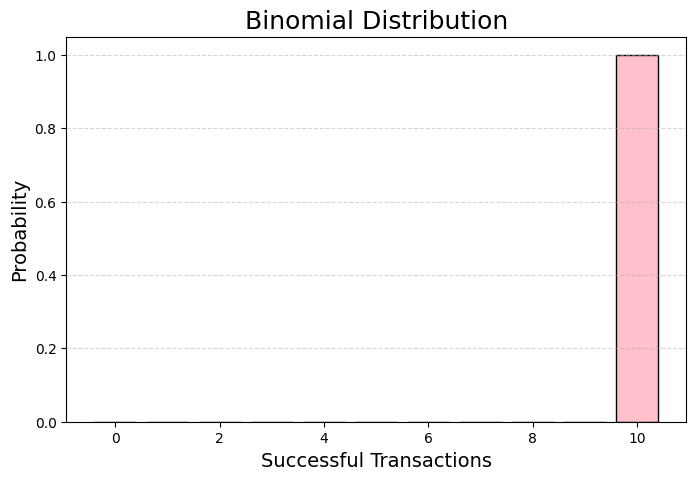

In [41]:
x = np.arange(0, 11)
binomial = stats.binom.pmf(x, 10, p)
plt.figure(figsize=(8,5))
plt.bar(
    x,
    binomial,
    color="pink",
    edgecolor="black")
plt.title("Binomial Distribution", fontsize=18)
plt.xlabel("Successful Transactions", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [16]:
#task2
lam = df["transaction_count"].mean()
print("Lambda Value:", lam)

Lambda Value: 2.8545454545454545


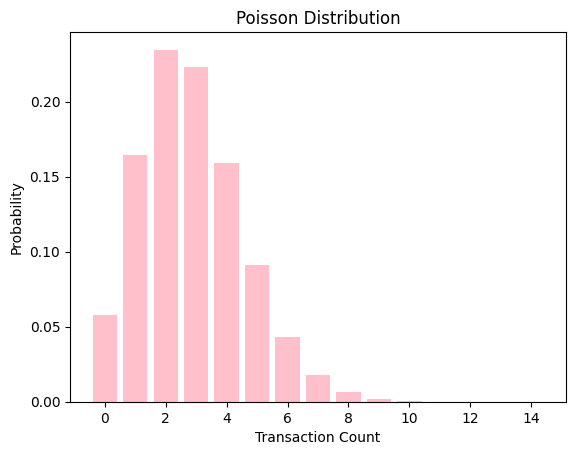

In [20]:
x = np.arange(0, 15)
poisson_data = poisson.pmf(x, lam)
plt.bar(x, poisson_data, color='pink')
plt.title("Poisson Distribution")
plt.xlabel("Transaction Count")
plt.ylabel("Probability")
plt.show()

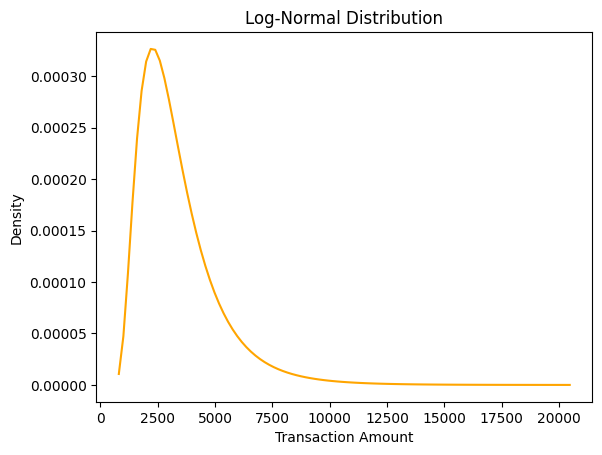

In [23]:
#task3
data = df["transaction_amount"]
shape, loc, scale = lognorm.fit(data)
x = np.linspace(data.min(), data.max(), 100)
pdf = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, color='orange')
plt.title("Log-Normal Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()

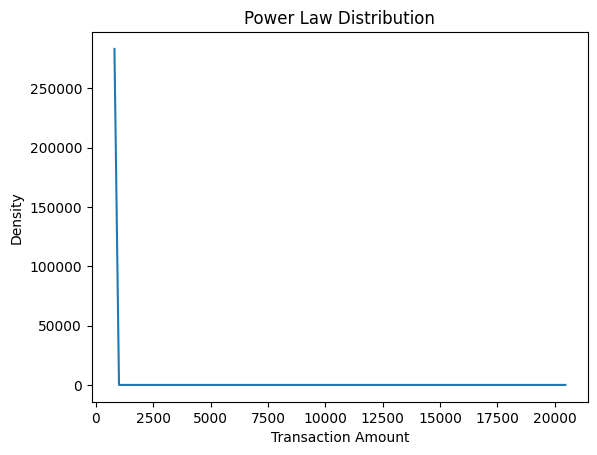

In [25]:
a, loc, scale = powerlaw.fit(data)
pdf = powerlaw.pdf(x, a, loc, scale)
plt.plot(x, pdf)
plt.title("Power Law Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()

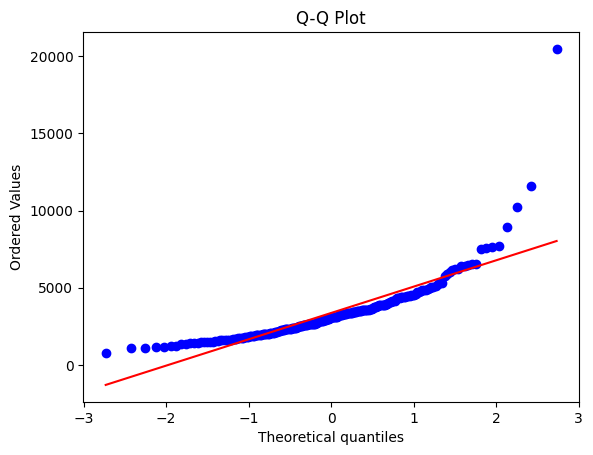

In [27]:
#task4
probplot(
    df["transaction_amount"],
    dist="norm",
    plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [29]:
#task5
positive_data = df["transaction_amount"] + 1
transformed_data, lambda_value = boxcox(positive_data)
print("Lambda Value:", lambda_value)

Lambda Value: -0.18123612911845818


In [31]:
df["z_score"] = zscore(df["transaction_amount"])
print(df[["transaction_amount", "z_score"]].head())

   transaction_amount   z_score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179


In [33]:
mean = df["transaction_amount"].mean()
std = df["transaction_amount"].std()
probability = 1 - norm.cdf(5000, mean, std)
print("Probability of transactions exceeding ₹5000:", probability)

Probability of transactions exceeding ₹5000: 0.20517209567554384


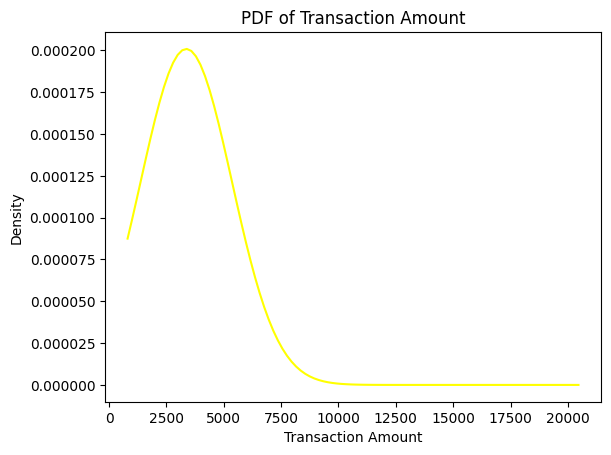

In [39]:
data = df["transaction_amount"]
mean = data.mean()
std = data.std()
x = np.linspace(data.min(), data.max(), 100)
pdf = norm.pdf(x, mean, std)
plt.plot(x, pdf, color='yellow')
plt.title("PDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.show()

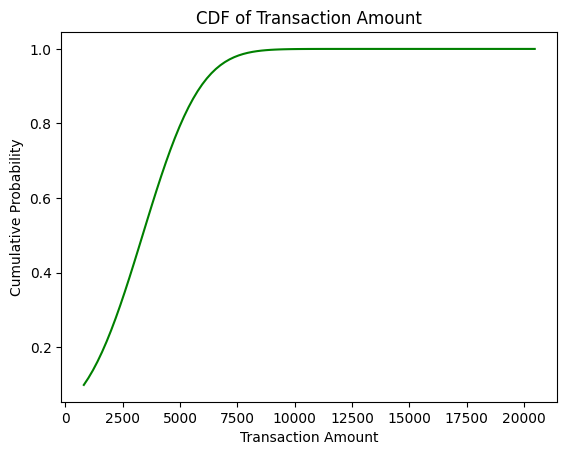

In [38]:
cdf = norm.cdf(x, mean, std)
plt.plot(x, cdf, color='green')
plt.title("CDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Cumulative Probability")
plt.show()

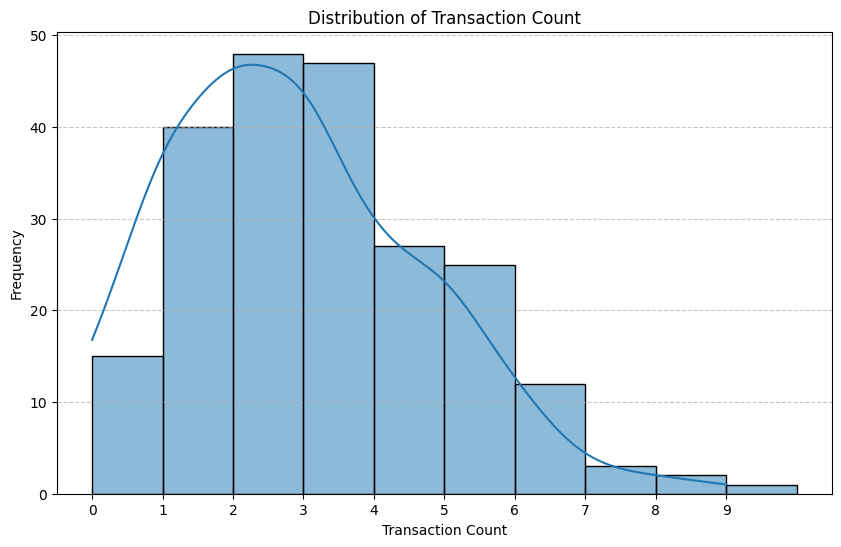

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df['transaction_count'], bins=range(int(df['transaction_count'].min()), int(df['transaction_count'].max()) + 2), kde=True)
plt.title('Distribution of Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel('Frequency')
plt.xticks(np.arange(df['transaction_count'].min(), df['transaction_count'].max() + 1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_8094/666617228.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='transaction_amount', data=df, palette='viridis')


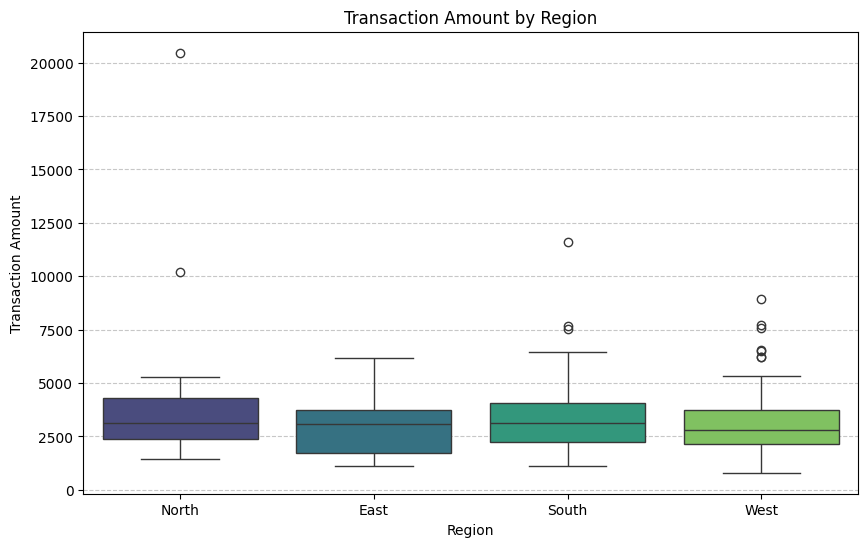

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='transaction_amount', data=df, palette='viridis')
plt.title('Transaction Amount by Region')
plt.xlabel('Region')
plt.ylabel('Transaction Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_8094/2645172860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='transaction_status', data=df, palette='magma')


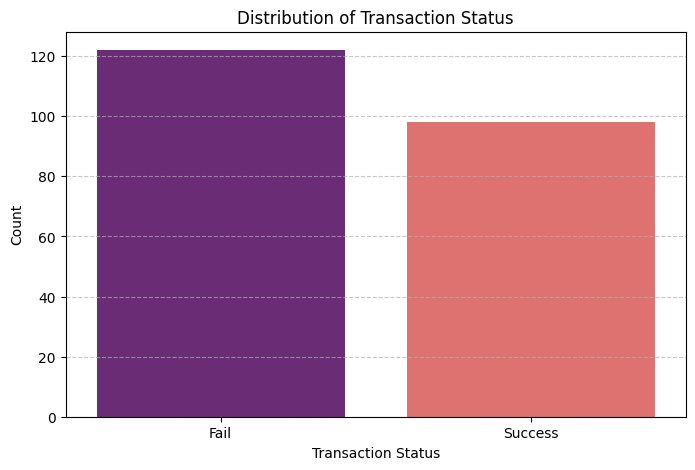

In [47]:
plt.figure(figsize=(8, 5))
sns.countplot(x='transaction_status', data=df, palette='magma')
plt.title('Distribution of Transaction Status')
plt.xlabel('Transaction Status')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The transaction dataset was analyzed using different probability distributions and statistical techniques.

Bernoulli and Binomial distributions were used to model transaction occurrence and weekly transaction success probability.

Poisson distribution was applied to model transaction counts.

Log-Normal and Power Law distributions were used for transaction amounts because the data was positively skewed.

The Q-Q Plot showed that the data does not perfectly follow normal distribution.

Box-Cox transformation helped stabilize the variance.

Z-score analysis identified how far transaction values deviated from the mean.

PDF and CDF plots helped understand the probability and cumulative behavior of transaction amounts.

Overall, the Log-Normal distribution provided a better fit for transaction amount analysis.**bold text**